In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import re

Load Dataset

In [137]:
df = pd.read_csv("dataset/subride.csv")

In [138]:
df.head(5)

,score,app,review,translated_review,label
0,5,Maxim,semoga kedepannya talangan g susah dapatnya ka...,Hopefully in the future it won’t be so hard to...,1
1,3,Grab,tolong buat pusat grab perbaiki lagi jangan di...,"Please Grab HQ, improve your system — don't su...",1
2,1,Gojek,woi gojek kalo mau bikin verifikasi minimal bi...,"Hey Gojek, if you're going to do face verifica...",1
3,1,Maxim,aplikasi ini sangat baiktapi yang bikin jelek ...,"This app is great, but what ruins it are the d...",1
4,3,Maxim,maxsim bagus tapi sayang nya nga ada fitur tel...,"Maxim is good, but sadly it doesn’t have a cal...",0


In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   score              1338 non-null   int64
 1   app                1338 non-null   str  
 2   review             1338 non-null   str  
 3   translated_review  1338 non-null   str  
 4   label              1338 non-null   int64
dtypes: int64(2), str(3)
memory usage: 465.4 KB


In [140]:
df.shape

(1338, 5)

Text(0.5, 1.0, 'Distribusi Label')

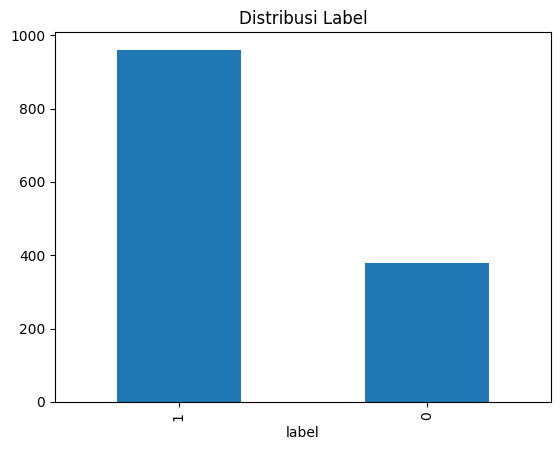

In [141]:
df["label"].value_counts().plot(kind="bar")
plt.title("Distribusi Label")

In [142]:
df.isnull().sum()

score                0
app                  0
review               0
translated_review    0
label                0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(0)

Data Preprocessing

In [144]:
df

,score,app,review,translated_review,label
0,5,Maxim,semoga kedepannya talangan g susah dapatnya ka...,Hopefully in the future it won’t be so hard to...,1
1,3,Grab,tolong buat pusat grab perbaiki lagi jangan di...,"Please Grab HQ, improve your system — don't su...",1
2,1,Gojek,woi gojek kalo mau bikin verifikasi minimal bi...,"Hey Gojek, if you're going to do face verifica...",1
3,1,Maxim,aplikasi ini sangat baiktapi yang bikin jelek ...,"This app is great, but what ruins it are the d...",1
4,3,Maxim,maxsim bagus tapi sayang nya nga ada fitur tel...,"Maxim is good, but sadly it doesn’t have a cal...",0
...,...,...,...,...,...
1333,5,Gojek,kaktlg tambahin pendapatnya bang ojol kak apal...,Please add opinions from the ojol (motorcycle ...,1
1334,2,Maxim,tolong dong di perbaiki lagi untuk maps nya sa...,"Please fix the maps, I want to go to work and ...",1
1335,3,Gojek,mau download bukti transaksi kok gak ke downlo...,I want to download the transaction receipt but...,0
1336,1,Gojek,tolong di suspen buat driver2 bintang 5 nakal ...,Please suspend those naughty 5-star drivers wh...,1


In [145]:
df = df[['review', 'label']]

In [146]:
df

,review,label
0,semoga kedepannya talangan g susah dapatnya ka...,1
1,tolong buat pusat grab perbaiki lagi jangan di...,1
2,woi gojek kalo mau bikin verifikasi minimal bi...,1
3,aplikasi ini sangat baiktapi yang bikin jelek ...,1
4,maxsim bagus tapi sayang nya nga ada fitur tel...,0
...,...,...
1333,kaktlg tambahin pendapatnya bang ojol kak apal...,1
1334,tolong dong di perbaiki lagi untuk maps nya sa...,1
1335,mau download bukti transaksi kok gak ke downlo...,0
1336,tolong di suspen buat driver2 bintang 5 nakal ...,1


In [147]:
df['review'].sample(100, random_state=22).tolist()

['aplikasi nya sudah bagusbanyak fitur dan animasi yang menarik menurut saya aplikasi ojol paling bagus adalah gojekmungkin perlu ditingkatkan lagi secara manajemen dan juga efektifitas operasional sehingga harga sahamnya bisa naik',
 'lambat sudah naikin harga pun tak da yang mau jemput sye dikota besar pun mcm tak da driver yg mau ambik',
 'aplikasi bagus dan sangat membantu dan tarif ongkirnya standar sukses terus gojek saya beri rating 100',
 'tolong dong diperiksa semua driver nyaaa apalagi daerah jambi kalo malam banyak yang pada upping price sampe 2 kali lipat bukan nya ga mampu tapi masa sampe segitu nya',
 'makasi ya gojek sering dapet diskon kalo pesen makan sangat membantu kalo pas lagi laper dan males beli makan',
 'aplikasi ojol yg memang murah sih menurutkutdk kalah dgn yg laintrus tingkatkan lgklo bs adakan voucher2 dong kaya di ojol2 yg lain',
 'sudah instal dan uninstall yang kesekian x nyapesan maxim car selalu ditolak ma drivernyapadahal di map terlihat banyak driver

In [148]:
from collections import Counter

all_words = " ".join(df['review']).lower().split()

Counter(all_words).most_common(100)

[('driver', 949),
 ('di', 713),
 ('nya', 553),
 ('saya', 485),
 ('gojek', 476),
 ('dan', 412),
 ('yg', 395),
 ('yang', 356),
 ('aplikasi', 332),
 ('ada', 331),
 ('tidak', 306),
 ('ga', 278),
 ('tolong', 258),
 ('ini', 249),
 ('mau', 227),
 ('bisa', 219),
 ('grab', 215),
 ('tapi', 211),
 ('lagi', 200),
 ('drivernya', 193),
 ('untuk', 192),
 ('lama', 185),
 ('padahal', 181),
 ('sangat', 179),
 ('gak', 179),
 ('sama', 170),
 ('banyak', 170),
 ('ke', 164),
 ('udah', 164),
 ('dari', 161),
 ('buat', 160),
 ('sudah', 158),
 ('malah', 156),
 ('aja', 156),
 ('juga', 152),
 ('lebih', 149),
 ('banget', 147),
 ('dengan', 145),
 ('cancel', 139),
 ('maxim', 131),
 ('jadi', 131),
 ('selalu', 131),
 ('jauh', 128),
 ('susah', 121),
 ('kalo', 118),
 ('ya', 113),
 ('karena', 110),
 ('kasih', 106),
 ('pake', 104),
 ('dapat', 104),
 ('gocar', 101),
 ('sering', 98),
 ('nunggu', 96),
 ('kalau', 95),
 ('pakai', 95),
 ('baik', 93),
 ('minta', 93),
 ('makin', 92),
 ('dapet', 90),
 ('terus', 88),
 ('ramah', 85),

In [149]:
import re

def remove_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

print(remove_repeated_chars("bagusss"))


bagus


In [150]:
df["review"] = df["review"].apply(remove_repeated_chars)

In [151]:
for text in df["review"].sample(20, random_state=22):
    print(text)

aplikasi nya sudah bagusbanyak fitur dan animasi yang menarik menurut saya aplikasi ojol paling bagus adalah gojekmungkin perlu ditingkatkan lagi secara manajemen dan juga efektifitas operasional sehingga harga sahamnya bisa naik
lambat sudah naikin harga pun tak da yang mau jemput sye dikota besar pun mcm tak da driver yg mau ambik
aplikasi bagus dan sangat membantu dan tarif ongkirnya standar sukses terus gojek saya beri rating 100
tolong dong diperiksa semua driver nya apalagi daerah jambi kalo malam banyak yang pada upping price sampe 2 kali lipat bukan nya ga mampu tapi masa sampe segitu nya
makasi ya gojek sering dapet diskon kalo pesen makan sangat membantu kalo pas lagi laper dan males beli makan
aplikasi ojol yg memang murah sih menurutkutdk kalah dgn yg laintrus tingkatkan lgklo bs adakan voucher2 dong kaya di ojol2 yg lain
sudah instal dan uninstall yang kesekian x nyapesan maxim car selalu ditolak ma drivernyapadahal di map terlihat banyak driver terdekat harga juga tiba be

In [152]:
Counter(all_words).most_common(50)

[('driver', 949),
 ('di', 713),
 ('nya', 553),
 ('saya', 485),
 ('gojek', 476),
 ('dan', 412),
 ('yg', 395),
 ('yang', 356),
 ('aplikasi', 332),
 ('ada', 331),
 ('tidak', 306),
 ('ga', 278),
 ('tolong', 258),
 ('ini', 249),
 ('mau', 227),
 ('bisa', 219),
 ('grab', 215),
 ('tapi', 211),
 ('lagi', 200),
 ('drivernya', 193),
 ('untuk', 192),
 ('lama', 185),
 ('padahal', 181),
 ('sangat', 179),
 ('gak', 179),
 ('sama', 170),
 ('banyak', 170),
 ('ke', 164),
 ('udah', 164),
 ('dari', 161),
 ('buat', 160),
 ('sudah', 158),
 ('malah', 156),
 ('aja', 156),
 ('juga', 152),
 ('lebih', 149),
 ('banget', 147),
 ('dengan', 145),
 ('cancel', 139),
 ('maxim', 131),
 ('jadi', 131),
 ('selalu', 131),
 ('jauh', 128),
 ('susah', 121),
 ('kalo', 118),
 ('ya', 113),
 ('karena', 110),
 ('kasih', 106),
 ('pake', 104),
 ('dapat', 104)]

Normalisasi

In [153]:
normalization_dict = {
    "yg": "yang",
    "ga": "tidak",
    "gk": "tidak",
    "gak": "tidak",
    "pake": "pakai",
    "udh": "sudah",
    "baiktapi": "baik tapi",
    "udah": "sudah",
    "blm": "belum",
    "bgt": "banget",
    "sebenar":"sebenarnya",
    "kl": "kalau",
    "klo": "kalau",
    "pdhl": "padahal",
    "jg": "juga",
    "knp": "kenapa",
    "lg": "lagi",
    "sdah": "sudah",
    "uda": "sudah",
    "kaktlg":"kak tolong",
    "tlg":"tolong",
    "mw":"mau",
    "ssuh":"susah",
    "knapa":"kenapa",
    "hrg":"harga",
    "ttp":"tetap",
    "spy":"supaya",
    "gw":"saya",
    "bagustapi":"bagus tapi",
    "sekarangtolong":"sekarang tolong",
    "jln":"jalan",
    "dg":"dengan",
    "otw":"on the way",
    "dll":"dan lain-lain",
    "bgt":"banget",
    "tiba2": "tiba tiba",
    "bener2": "bener bener",
    "jauh2": "jauh jauh",
    "lama2": "lama lama",
    "awal2": "awal awal",
    "murah2": "murah murah",
    "marah2": "marah marah",
    "dimaki2": "dimaki dimaki",
    "buru2": "buru buru",
    "hati2": "hati hati"

    
}

def normalize_slang(text):
    words = text.split()

    normalized_words = [
        normalization_dict.get(word, word)
        for word in words
    ]

    return " ".join(normalized_words)

In [154]:
df['review'] = df['review'].apply(normalize_slang)

In [155]:
df

,review,label
0,semoga kedepannya talangan g susah dapatnya ka...,1
1,tolong buat pusat grab perbaiki lagi jangan di...,1
2,woi gojek kalo mau bikin verifikasi minimal bi...,1
3,aplikasi ini sangat baik tapi yang bikin jelek...,1
4,maxsim bagus tapi sayang nya nga ada fitur tel...,0
...,...,...
1333,kak tolong tambahin pendapatnya bang ojol kak ...,1
1334,tolong dong di perbaiki lagi untuk maps nya sa...,1
1335,mau download bukti transaksi kok tidak ke down...,0
1336,tolong di suspen buat driver2 bintang 5 nakal ...,1


Stopwords Removal

In [156]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [157]:
important_words = {
    "tidak",
    "bukan",
    "jangan"
}

stopwords = stopwords - important_words

In [158]:
def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stopwords]
    return " ".join(filtered)

In [159]:
df['review'] = df['review'].apply(remove_stopwords)

In [160]:
df

,review,label
0,semoga kedepannya talangan g susah dapatnya ka...,1
1,buat pusat grab perbaiki jangan dikit tangguhk...,1
2,woi gojek kalo mau bikin verifikasi minimal de...,1
3,aplikasi sangat baik bikin jelek drive cara bi...,1
4,maxsim bagus sayang nya nga fitur telpon buat ...,0
...,...,...
1333,kak tambahin pendapatnya bang ojol kak kalau m...,1
1334,dong perbaiki maps nya mau berangkat kerja rut...,1
1335,mau download bukti transaksi kok tidak downloa...,0
1336,suspen buat driver2 bintang 5 nakal sengaja me...,1


In [161]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [162]:
print(stemmer.stem("drivernya"))
print(stemmer.stem("aplikasinya"))
print(stemmer.stem("pelayanannya"))
print(stemmer.stem("menunggu"))
print(stemmer.stem("membantu"))

drivernya
aplikasi
layan
tunggu
bantu


In [163]:
from collections import Counter

words = " ".join(df["review"]).split()

counter = Counter(words)

print(counter["drivernya"])
print(counter["aplikasinya"])
print(counter["ordernya"])
print(counter["customernya"])

194
32
0
0


In [164]:
def remove_suffix_nya(text):
    words = text.split()

    processed = []

    for word in words:
        if len(word) > 4 and word.endswith("nya"):
            word = word[:-3]

        processed.append(word)

    return " ".join(processed)

In [165]:
df['review'] = df['review'].apply(remove_suffix_nya)

In [166]:
from collections import Counter

words = " ".join(df["review"]).split()

counter = Counter(words)

print(counter["drivernya"])
print(counter["aplikasinya"])
print(counter["ordernya"])
print(counter["customernya"])
print(counter["sebenar"])

0
0
0
0
2


In [167]:
def stemming(text):
    return stemmer.stem(text)

In [168]:
df["stemmed_review"] = df["review"].apply(stemming)

df.to_csv("stemmed_reviews.csv", index=False)

In [169]:
df_kedua = pd.read_csv("stemmed_reviews.csv")

In [170]:
df_kedua

,review,label,stemmed_review
0,semoga kedepan talangan g susah dapat karna ju...,1,moga depan talang g susah dapat karna jual pak...
1,buat pusat grab perbaiki jangan dikit tangguhk...,1,buat pusat grab baik jangan dikit tangguh buat...
2,woi gojek kalo mau bikin verifikasi minimal de...,1,woi gojek kalo mau bikin verifikasi minimal de...
3,aplikasi sangat baik bikin jelek drive cara bi...,1,aplikasi sangat baik bikin jelek drive cara bi...
4,maxsim bagus sayang nya nga fitur telpon buat ...,0,maxsim bagus sayang nya nga fitur telpon buat ...
...,...,...,...
1333,kak tambahin pendapat bang ojol kak kalau musi...,1,kak tambahin dapat bang ojol kak kalau musim h...
1334,dong perbaiki maps nya mau berangkat kerja rut...,1,dong baik maps nya mau berangkat kerja rute le...
1335,mau download bukti transaksi kok tidak downloa...,0,mau download bukti transaksi kok tidak downloa...
1336,suspen buat driver2 bintang 5 nakal sengaja me...,1,suspen buat driver2 bintang 5 nakal sengaja ma...


In [171]:
no_stem = df_kedua[["review", "label"]]

In [172]:
no_stem

,review,label
0,semoga kedepan talangan g susah dapat karna ju...,1
1,buat pusat grab perbaiki jangan dikit tangguhk...,1
2,woi gojek kalo mau bikin verifikasi minimal de...,1
3,aplikasi sangat baik bikin jelek drive cara bi...,1
4,maxsim bagus sayang nya nga fitur telpon buat ...,0
...,...,...
1333,kak tambahin pendapat bang ojol kak kalau musi...,1
1334,dong perbaiki maps nya mau berangkat kerja rut...,1
1335,mau download bukti transaksi kok tidak downloa...,0
1336,suspen buat driver2 bintang 5 nakal sengaja me...,1


In [173]:
no_stem = no_stem.to_csv("no_stem_reviews.csv", index=False)

In [174]:
df_stem = df_kedua[['stemmed_review', 'label']]

In [175]:
df_stem = df_stem.to_csv("stemmed_reviews.csv", index=False)